# Selen MOĞOL Ödev 2 

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
ind = pd.read_csv('industries(2.0).csv')

In [55]:
app = pd.read_csv('applications(2.0).csv')

In [6]:
print(ind.shape)
print(app.shape)

(37, 2)
(13315, 10)


In [57]:
print(ind.dtypes)
print(app.dtypes)

Industry    object
Score        int64
dtype: object
Applied at          object
Amount             float64
Age                  int64
Gender              object
Industry            object
Marital status      object
External Rating    float64
Education level     object
Location            object
applicant_id        object
dtype: object


# Soru 1

#### 1. Jupyter Notebook'ta applications.csv dosyasını Pandas - DataFrame olarak yükleyin ve verileri temizleyin:

* applicant_id sütunundaki tekrar eden değerleri kaldırın.
* 'External Rating' alanındaki eksik değerleri sıfırla doldurun.
* 'Education level' alanındaki eksik değerleri "Ortaokul" metni ile doldurun.

In [59]:
# Veriyi başvuru tarihine göre sıraladım.
app.sort_values(by='Applied at', ascending=False, inplace=True)

# Tekrar eden applicant_id'yi kaldırarak, en son başvuru yapan id'yi veri setimde tuttum.
# Veri setimde 13.315 satırım varken 13.278 satıra düştü.

app.drop_duplicates(subset='applicant_id', keep='last', inplace=True)

In [10]:
#External Rating kolonundaki eksik değerlerin nasıl gözüktüğünü kontrol etmek için 'app[app['External Rating'].isna()]' kodunu yazdım.
#Değerlerin NaN olduğunu gördüm.'fillna' formülü ile de NaN değerleri ile değiştirdim.

app['External Rating'] = app['External Rating'].fillna(0)

In [11]:
#Replace fonksiyonu ile 'Education level' alanındaki eksik değerleri "Ortaokul/Середня " metni ile doldurdum.

app['Education level'] = app['Education level'].replace(to_replace=np.nan, value='Середня')

# Soru 2
#### Bu DataFrame'e industries.csv dosyasından gelen verileri, yani sektörlerin derecelendirmelerini ekleyin.¶

In [13]:
# deneme = app['Industry'].value_counts()  ve print(len(deneme)) fonksiyonları ile iki dosyadaki 'industury' değerlerinin aynı olup olmadığını kontrol ettim.
# Inner join ile industry scorelarını app veri setine ekledim.

merged = pd.merge(app, ind , on = 'Industry', how = 'inner')

# Soru 3

#### Başvuru puanını aşağıdaki koşullara göre hesaplayın:
* Puan 0 ile 100 arasında bir sayı olmalıdır.
* Puan, başvurunun 6 kriterine göre verilen puanların toplamı olmalıdır.
* 'Amount' değeri eksikse veya 'External Rating' sıfırsa, puan sıfır olmalıdır.

##### Puan nasıl hesaplanır:
* Başvuranın yaşı 35 ile 55 arasındaysa, puana 20 puan eklenir.
* Başvuru hafta sonu yapılmamışsa, puana 20 puan eklenir.
* Başvuran evliyse, puana 20 puan eklenir.
* Başvuran Kiev veya çevresinde bulunuyorsa, puana 10 puan eklenir.
* industries.csv tablosundaki 'Score' değeri de başvuruya eklenir (0 ile 20 puan arasında).
* 'External Rating' 7 veya daha büyükse, puana 20 puan eklenir.
* 'External Rating' 2 veya daha küçükse, puandan 20 puan çıkarılır.

In [15]:
def application_score(point):
    score = 0

    # Başvuranın yaşı 35 ile 55 arasındaysa, puana 20 puan ekle.
    if 35 <= point['Age'] <= 55:
        score += 20

    # Başvuru hafta sonu yapılmamışsa, puana 20 puan ekle.
    # Tarihi datetime formatına çevirdim ve hafta sonu olup olmadığını kontrol ettim.
    
    applied_date = pd.to_datetime(point['Applied at'], errors='coerce', dayfirst=False)
    if applied_date not in [pd.NaT] and applied_date.strftime("%A") not in ['Saturday', 'Sunday']:
        score += 20

    # Başvuran evliyse, puana 20 puan ekle.
    if point['Marital status'] == 'Married':  
        score += 20

    # Başvuran Kiev veya çevresinde bulunuyorsa, puana 10 puan ekle.
    # Veri Setinde Kiev olan her şeyi getirdin diye sadece şehri kullandım.
    
    if 'Київ' in str(point['Location']):   
        score += 10

    # industries.csv tablosundaki 'Score' değeri de başvuruya ekle (0 ile 20 puan arasında)
    
    score += point['Score'] if pd.notna(point['Score']) else 0  

    # External Rating kontrolü ekledim.
    if point['External Rating'] >= 7:
        score += 20
    elif point['External Rating'] <= 2:
        score -= 20

    # Amount veya External Rating eksikse veya sıfırsa skor sıfır olmalı
    if pd.isna(point['Amount']) or point['External Rating'] == 0:
        return 0  

    # Skorun 0 ile 100 arasında olması
    return max(0, min(100, score)) 
    

# Fonksiyonu tüm satırlara uygula
merged['Calculated_Score'] = merged.apply(application_score, axis=1) 


# Soru 4

#### Sonuçta elde edilen tabloda sadece puanı sıfırdan büyük olan başvuruları bırakın; çünkü bu başvurular kabul edilmiş sayılacak.


In [17]:
accepted_applications = merged[merged['Calculated_Score'] > 0]
zero = merged[merged['Calculated_Score'] == 0]

print(f"Başvuru koşulunu sağlayan {len(merged)} kişi arasından {len(zero)} kişinin başvurusu uygun görülmedi, {len(accepted_applications)} kişinin başvurusu kabul edildi.")

Başvuru koşulunu sağlayan 13278 kişi arasından 720 kişinin başvurusu uygun görülmedi, 12558 kişinin başvurusu kabul edildi.


In [61]:
accepted_applications['Calculated_Score'].mean()

49.94306418219462

# Soru 5

#### Sonuç tablosundaki verileri başvurunun yapıldığı haftaya göre gruplayın ve her hafta için kabul edilen başvuruların ortalama puanını bir grafik üzerinde gösterin.


In [20]:
# Veri setimde tarih bilgilerinin yer aldığı sütunda iki farklı yazım şekli vardı. 
# Bir kısımda saniye bilgisi varken diğer kısımda sadece saat ve dakika vardı. 
# Bu nedenle saniye bilgisi bulunmayanlara 00 saniye bilgisi ekleyerek tek bir format haline getirdim.

accepted_applications.loc[:, 'Applied at'] = accepted_applications['Applied at'].apply(lambda x: x + ':00' if len(x) == 16 else x)

In [21]:
#Applied at datatypını kontrol ettim.

accepted_applications['Applied at'].dtype

dtype('O')

In [22]:
accepted_applications = accepted_applications.copy()

In [23]:
#Applied at data typını datetime a çevirdim. 

accepted_applications['Applied at'] = pd.to_datetime(
    accepted_applications['Applied at'], errors='coerce'
)

In [63]:
#Applied at data typını kontrol ettim.

accepted_applications['Applied at'].dtype

dtype('<M8[ns]')

In [25]:
# Başvuru tarihlerini yıl-haftalara çevirdim.

accepted_applications.loc[:,'Year-Week'] = accepted_applications['Applied at'].dt.isocalendar().year.astype(str) + '-' + accepted_applications['Applied at'].dt.isocalendar().week.astype(str)

In [26]:
# Haftalık ortalama puanı hesapladım.

weekly_avg_score = accepted_applications.groupby('Year-Week')['Calculated_Score'].mean().round(2)

In [27]:
accepted_applications['Applied at'].min()

Timestamp('2022-11-30 10:26:37')

In [28]:
accepted_applications['Applied at'].max()

Timestamp('2023-01-09 11:38:00')

In [29]:
import matplotlib.pyplot as plt

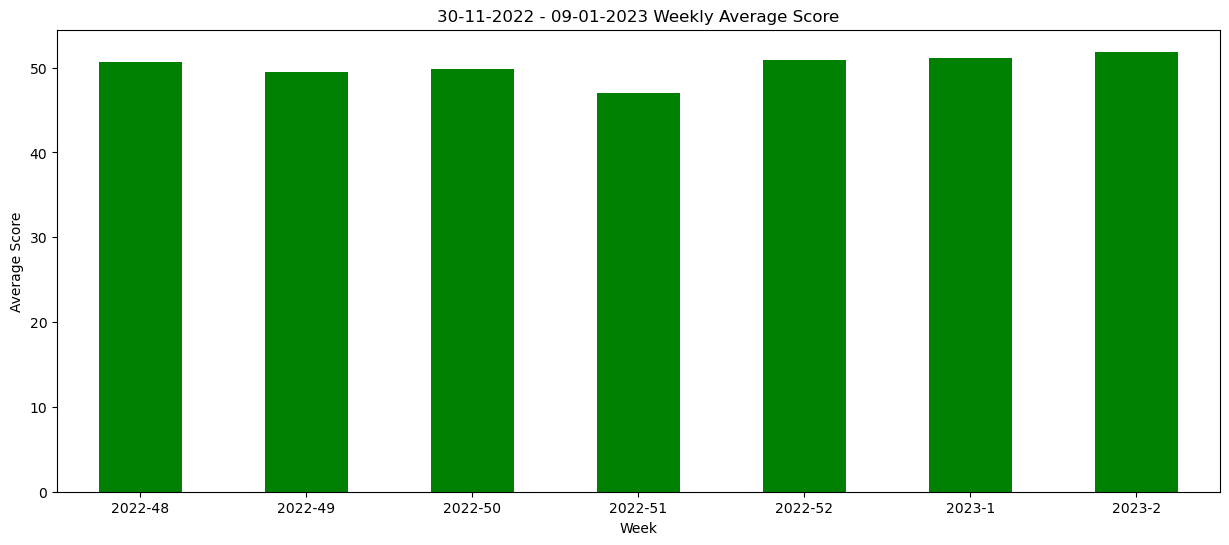

In [30]:
# Her hafta için geçerli ortalama puanı bar grafiği ile gösterdim.
# Veri setim 30-11-2022 - 09-01-2023 tarihleri arasındaki veriyi içeriyor.

plt.figure(figsize=(15, 6))
weekly_avg_score.plot(kind='bar', color='green')
plt.title('30-11-2022 - 09-01-2023 Weekly Average Score')
plt.xlabel('Week')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()